In [3]:
import numpy as np
import matplotlib.pyplot as plt

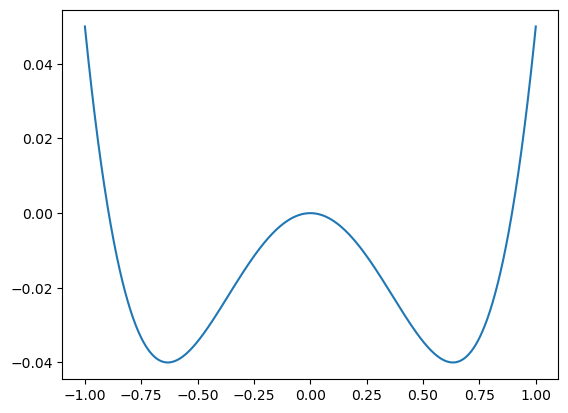

In [35]:
x = np. linspace(-1,1, 1000)
r = -1
u = 1
pot = 0.2*r*x**2 + u/4*x**4
plt.plot(x,pot)
plt.show
def f(x,r,u):
    return r*x**2 + u/4*x**4

In [96]:
rng = np.random.default_rng()

def teaching_time(teaching_rate):
    u = rng.random()
    tau = -np.log(u) / teaching_rate
    return tau

def brownian_motion(T,  x0, D,dt=1):

   x0 = np.asarray(x0)
   nsteps = int(T / dt)
   dW = rng.normal(0.0, np.sqrt(dt), size=(nsteps, x0.size))
   dx = np.sqrt(2 * D) * dW
   x = np.empty((nsteps + 1, x0.size))
   s = np.empty((nsteps + 1, x0.size))
   x[0] = x0
   s[0] = f(x0,-0.2,1)
   x[1:] = x0 + np.cumsum(dx, axis=0)
   s[1:] = f(x0 + np.cumsum(dx, axis=0),-0.2,1)
   return x,s

def one_step(w, Scores, Dmu, N, t, teaching_rate):
    tau = teaching_time(teaching_rate)
    w[t:t+tau,:] = brownian_motion(tau, w,Dmu)
def teaching( W,Score, N):
    i,j = rng.integers(0, N, size=2)
    if Score[i]<Score[j]:
        W[j] = W[i]
        Score[j] = Score[i]
    elif Score[ j]<Score[i]:
        W[i] = W[j]
        Score[i] = Score[j]
    else: 
        u = rng.random()
        if u<0.5: 
            Score[i] = Score[j]
            W[i] = W[j]
        else:
            Score[j] = Score[i]
            W[j] = W[i]
    return W, Score
   
        

In [103]:
teaching_rate = 10
Dmu = 1e-6

T = 1000000
N = 1000
w0 = np.random.uniform(-1, 1, N)
score_0 = f(w0,-0.2,1)

W = np.zeros((T,N))
Score = np.zeros((T,N))

W[0,:] = w0
Score[0,:] = score_0

t = 0
while t<T-1:
    time = teaching_time(teaching_rate)
    tau = max(1, int(np.floor(time)))
    tau = min(tau, T - 1 - t)
    W[t:t+tau+1, :], Score[t:t+tau+1, :]  = brownian_motion(tau, W[t, :], Dmu, dt=1)
    Score[t:t+tau+1, :] = f(W[t:t+tau+1, :], -0.2, 1)
    W[t+tau, :], Score[t+tau, :] = teaching(W[t+tau, :], Score[t+tau, :], N)
    t+=tau

    
    

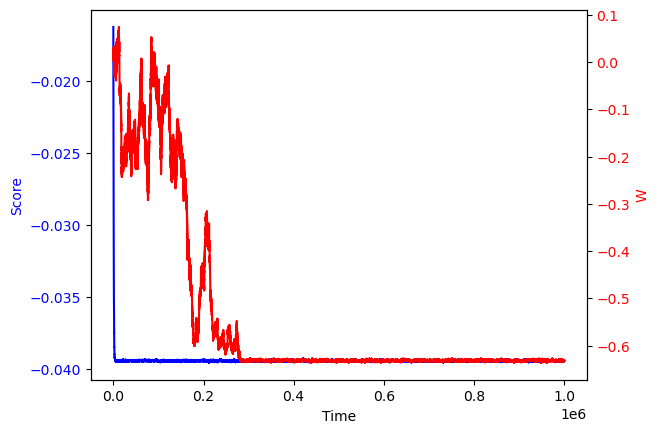

In [104]:
score_mean = np.mean(Score, axis=1)
w_mean = np.mean(W, axis=1)

fig, ax1 = plt.subplots()

# Axe gauche (Score)
ax1.plot(score_mean, color='blue', label="Score")
ax1.set_ylabel("Score", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Axe droit (W)
ax2 = ax1.twinx()
ax2.plot(w_mean, color='red', label="W")
ax2.set_ylabel("W", color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_xlabel("Time")

plt.show()

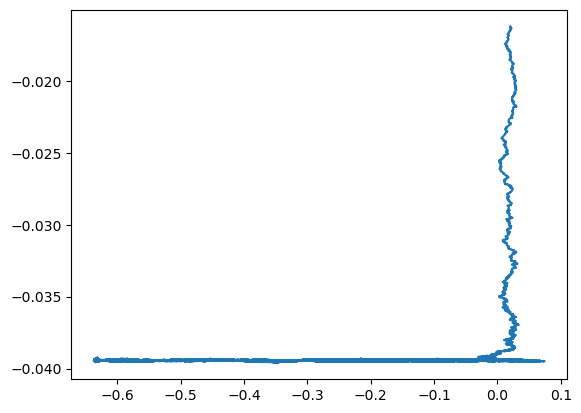

In [105]:
plt.plot(w_mean,score_mean)

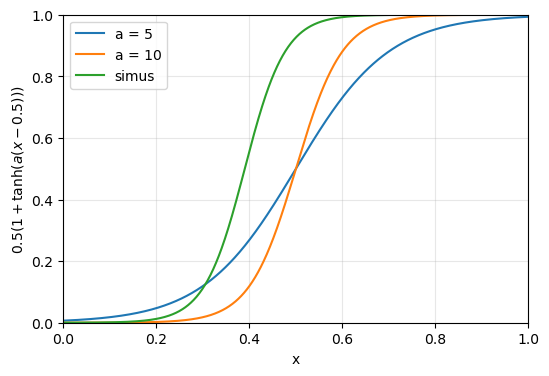

In [110]:
import numpy as np
import matplotlib.pyplot as plt

# Domaine
x = np.linspace(0, 1, 1000)

# Valeurs de a
a_values = [5, 10]# 6, 7,8,9,

plt.figure(figsize=(6,4))
y0 = 0.5 * (1 + np.tanh(11.5 * (x - 0.39)))
for a in a_values:
    y = 0.5 * (1 + np.tanh(a * (x - 0.5)))

    plt.plot(x, y, label=f"a = {a}")
plt.plot(x, y0, label=f"simus")
plt.xlabel("x")
plt.ylabel(r"$0.5(1+\tanh(a(x-0.5)))$")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()